# Project - 02: L Layered Deep Neural Network

In [144]:
# Importing necessary libraries
import time
import pickle # For saving parameters of the trained model
import random
import numpy as np
import matplotlib.pyplot as plt

In [123]:
# Loading datasets
X_train = np.loadtxt("/content/deep neural network/cat_train_x.csv", delimiter = ",")/255.0
Y_train = np.loadtxt("/content/deep neural network/cat_train_y.csv", delimiter = ",").reshape(1, X_train.shape[1])
X_test = np.loadtxt("/content/deep neural network/cat_test_x.csv", delimiter = ",")/255.0
Y_test = np.loadtxt("/content/deep neural network/cat_test_y.csv", delimiter = ",").reshape(1, X_test.shape[1])

print("Shape of X train: ", X_train.shape)
print("Shape of Y train: ", Y_train.shape)
print("Shape of X test: ", X_test.shape)
print("Shape of Y test: ", Y_test.shape)

Shape of X train:  (12288, 209)
Shape of Y train:  (1, 209)
Shape of X test:  (12288, 50)
Shape of Y test:  (1, 50)


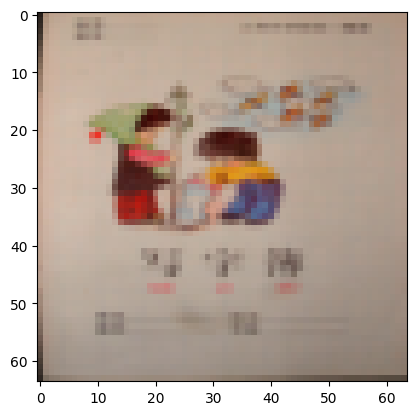

In [124]:
# Displaying an image
index = random.randrange(0, X_train.shape[1])
plt.imshow(X_train[:, index].reshape(64,64,3)) # '64' is 'height', '64' is 'width' and '3' represents 'channels' i.e., red, green, blue.
plt.show()


# Activation Functions

In [125]:
def sigmoid(Z):
  A = 1/(1 + np.exp(-Z))
  return A

def softmax(z):
  expZ = np.exp(z)
  return expZ/np.sum(expZ, axis = 0)

def relu(Z):
  A = np.maximum(0, Z)
  return A

def tanh(x):
  return np.tanh(x)

def derivative_relu(x):
  return np.array(x > 0, dtype = "float")

def derivative_tanh(x):
  return (1 - np.power(x, 2))


# Initializing Parameters

$The~shapes~are~given~as:$
<br><br>
$W_l = (n_l, n_{l-1})$
<br>

$B_l = (n_l, 1)$

Functionality to add any number of hidden layers in the neural network

In [126]:
# Randomly initializing parameters i.e., W & B
def initialize_parameters(layer_dims):
  L = len(layer_dims) - 1
  parameters = {}

  for l in range(1, L + 1):
    # print(l)
    parameters["W" + str(l)] = np.random.randn(layer_dims[l], layer_dims[l - 1])/np.sqrt(layer_dims[l]) # 'W_l/√W_l' to make values lie in range 1
    parameters["B" + str(l)] = np.random.randn(layer_dims[l], 1)

  return parameters
# initialize_parameters([10, 100, 200, 1]) # Output: '1, 2, 3' for 'W1, W2, W3' respectively.




In [127]:
# Tester block
layer_dims = [X_train.shape[0], 100, 200, Y_train.shape[0]] # [n0, n1, n2, n3]
params = initialize_parameters(layer_dims)

for l in range(1, len(layer_dims)):
  print("Shape of W" + str(l) + ":", params["W" + str(l)].shape)
  print("Shape of B" + str(l) + ":", params["B" + str(l)].shape, "\n")

Shape of W1: (100, 12288)
Shape of B1: (100, 1) 

Shape of W2: (200, 100)
Shape of B2: (200, 1) 

Shape of W3: (1, 200)
Shape of B3: (1, 1) 



# Forward Propagation

$Z_l = W_l * A_{l-1}~+~ B_l$
<br><br>
$A_l = f(Z_l)$
<br><br>
$Z_L = W_L * A_{L-1}~+~B_L$
<br><br>
$A_L = Sigmoid(Z_L) --> Output~layer$

In [143]:
def forward_propagation(X, parameters, activation = 'relu'):
  forward_cache = {}
  L = len(parameters) // 2 # '//' is division operator that returns only the integer part i.e., '5//2 = 2', and we are dividing by 2 because the parameters have 'W' and 'B' for each layer, so on.
  forward_cache["A0"] = X

  # Hidden layer functionality
  for l in range(1, L):
    forward_cache["Z" + str(l)] = parameters["W" + str(l)].dot(forward_cache["A" + str(l-1)]) + parameters["B" + str(l)] # Z_l = W_l * A_(l-1) + B_l

    if activation == "relu":
      forward_cache["A" + str(l)] = relu(forward_cache["Z" + str(l)]) # A_l = ReLU(Z_l)
    else:
      forward_cache["A" + str(l)] = tanh(forward_cache["Z" + str(l)]) # A_l = tanh(Z_l)

  # Output layer functionality
  forward_cache["Z" + str(L)]  = parameters["W" + str(L)].dot(forward_cache["A" + str(L-1)]) + parameters["B" + str(L)] # Z_L = W_L * A_(L-1) + B_L

  if forward_cache["Z" + str(L)].shape[0] == 1:
    forward_cache["A" + str(L)] = sigmoid(forward_cache["Z" + str(L)]) # A_L = Sigmoid(Z_L)
  else:
    forward_cache["A" + str(L)] = softmax(forward_cache["Z" + str(L)]) # A_L = Softmax(Z_L)


  return forward_cache['A' + str(L)], forward_cache

In [129]:
# Tester block
aL, forw_cache = forward_propagation(X_train, params, 'relu')

for l in range(len(params)//2 + 1):
  print("Shape of A" + str(l) + ":", forw_cache["A" + str(l)].shape, "\n")

Shape of A0: (12288, 209) 

Shape of A1: (100, 209) 

Shape of A2: (200, 209) 

Shape of A3: (1, 209) 



# Cost Function

**$For~Binary~Classification:$**
<br><br>
$Cost = -\frac{1}{m}\sum_{i=1}^{m}[y~*~log(a_L)~+~(1-y)~*~log(1-a_L)]$
<br><br><br>
**$For~Multi-Class~Classification:$**
<br><br>
$Cost = -\frac{1}{m}\sum_{i=1}^{m}\sum_{i=k}^{n}[y_k~*~log(a_k)]$

In [130]:
def compute_cost(AL, Y):
  m = Y.shape[1] # 209

  if Y.shape[0] == 1:
    cost = - (1./m) * np.sum(Y*np.log(AL) + (1 - Y)*np.log(1-AL)) # 1.0/m

  else:
    cost = - (1./m) * np.sum(y*np.log(AL))

  cost = np.squeeze(cost) # Squeezing the shape for e.g, 'np.squeeze([[[0, 3, 2, 4]]])' outputs 'array([0, 3, 2, 4])'

  return cost




# Backward Propagation

$For~Last~layer~(L)$
<br><br>
$dZ_L = A_L - Y$
<br><br>
$dW_L = (\frac{1}{m})~*~dZ_L~A_{L-1}^{T}$
<br><br>
$dB_L = (\frac{1}{m})~*~sum(dZ_L, 1)$
<br><br>
<br><br>
$For~All~Other~Layers~(l)$
<br><br>
$dZ_l = W_{l+1}^{T}~dZ_{l+1}~*~f'(Z_l)$
<br><br>
$dW_l = (\frac{1}{m})~*~dZ_l~A_{l-1}^{T}$
<br><br>
$dB_l = (\frac{1}{m})~*~sum(dZ_l,1)$



In [131]:
def backward_propagation(AL, Y, forward_cache, parameters, activation = "relu"):
  grads = {}
  L = len(parameters)//2
  m = Y.shape[1]

  # Functionality for last layer
  grads["dZ" + str(L)] = AL - Y # dZ_L = A_L - Y
  grads["dW" + str(L)] = (1./m) * np.dot(grads["dZ" + str(L)], forward_cache["A" + str(L-1)].T) # dW_L = (1/m) * dZ_L A_l-1^T
  grads["dB" + str(L)] = (1./m) * np.sum(grads["dZ" + str(L)], axis = 1, keepdims = True) # dB_L = 1/m * sum(dZ_L, 1)

  #Functionality for other layers that can be repea +ed for 'n' times for making 'n' layers
  for l in reversed(range(1, L)): # 'reversed(range(1, L))' goes from (L - 1), (L - 2), (L -3), ... till 1.
    if activation == "relu":
      grads["dZ" + str(l)] = np.dot(parameters["W" + str(l+1)].T, grads["dZ" + str(l+1)]) * derivative_relu(forward_cache["A" + str(l)]) # dZ_l = W_l^T + 1 dZ_l+1 ∗ f′(Z_l)
    else:
      grads["dZ" + str(l)] = np.dot(parameters["W" + str(l+1)].T, grads["dZ" + str(l+1)]) * derivative_tanh(forward_cache["A" + str(l)]) # dZ_l = W_l^T + 1 dZ_l+1 ∗ f′(Z_l)

    grads["dW" + str(l)] = (1./m) * np.dot(grads["dZ" + str(l)], forward_cache["A" + str(l-1)].T) # dW_l = (1/m) ∗ dZ_l A_l^T − 1
    grads["dB" + str(l)] = (1./m) * np.sum(grads["dZ" + str(l)], axis = 1, keepdims = True) # dB_l = (1/m) ∗ sum(dZ_l, 1)

  return grads

In [132]:
# Tester block
grads = backward_propagation(forw_cache["A" + str(3)], Y_train, forw_cache, params, "relu")

for l in reversed(range(1, len(grads)//3 + 1)):
  print("Shape of dZ" + str(l) + ":", grads["dZ" + str(l)].shape)
  print("Shape of dW" + str(l) + ":", grads["dW" + str(l)].shape)
  print("Shape of dB" + str(l) + ":", grads["dB" + str(l)].shape, "\n")

Shape of dZ3: (1, 209)
Shape of dW3: (1, 200)
Shape of dB3: (1, 1) 

Shape of dZ2: (200, 209)
Shape of dW2: (200, 100)
Shape of dB2: (200, 1) 

Shape of dZ1: (100, 209)
Shape of dW1: (100, 12288)
Shape of dB1: (100, 1) 



# Updating Parameters

$W_l = W_l - α~*~\frac{∂Cost}{∂W_l}$
<br><br>
$B_l = B_l - α~*~\frac{∂Cost}{∂B_l}$

In [133]:
def update_parameters(parameters, grads, learning_rate):
  L = len(parameters)//2

  for l in range(1, L + 1):
    parameters["W" + str(l)] = parameters["W" + str(l)] - learning_rate * grads["dW" + str(l)]
    parameters["B" + str(l)] = parameters["B" + str(l)] - learning_rate * grads["dB" + str(l)]
  return parameters

# Completing The Model

In [134]:
# Main function
def model(X, Y,learning_rate, layer_dims, activation = "relu", num_iterations = 100):

  parameters = initialize_parameters(layer_dims)
  cost_history = [] # List to store cost value of every iteration

  for i in range(0, num_iterations):
    AL, forward_cache = forward_propagation(X, parameters, activation = "relu")

    cost = compute_cost(AL, Y)
    cost_history.append(cost)
    grads = backward_propagation(AL, Y, forward_cache, parameters, activation)

    parameters = update_parameters(parameters, grads, learning_rate)

    if i % (num_iterations/10) == 0:
      print("\nIter: {} \t Cost: {} \t Train Accuracy: {}% \t Test Accuracy: {}%".format(i, cost, accuracy(X_train, Y_train, parameters, activation), accuracy(X_test, Y_test, parameters, activation)))

    # Making a progress bar after every slot of iterations
    if i % ((num_iterations/10)/20) == 0:
      print("==", end = '')

  return parameters, cost_history

# Evaluation Function Of The Model

In [135]:
def accuracy(X, Y, parameters, activation):
  preds, _ = forward_propagation(X, parameters, activation)
  m = Y.shape[1]

  if Y.shape[0] == 1:
    preds = np.array(preds > 0.5, dtype ="float") # [True, False, False] --> [1.0, 0.0, 0.0]
  else:
    Y = np.argmax(Y, axis = 0) # Converting 'Y' matrix to (1, any_number)
    preds = np.argmax(preds, axis = 0) # ()

  return np.round(np.sum(Y == preds)/m * 100, 3)  # Rounds the result to 3 deciml points.

# Training The Model

In [162]:
# '2' hidden layers neural network
# layer_dims = [X_train.shape[0], 100, 100, Y_train.shape[0]] # [n0, n1, n2, n3]
# l_rate = 0.0075
# iters = 1000

# parameters, cost_history = model(X_train, Y_train, learning_rate = l_rate, layer_dims = layer_dims,  activation = "tanh", num_iterations = iters)

# '3' hidden layers neural network
layer_dims = [X_train.shape[0], 1000, 1000, 1000, Y_train.shape[0]] # [n0, n1, n2, n3, n4]
l_rate = 0.0075
iters = 1000

parameters, cost_history = model(X_train, Y_train, learning_rate = l_rate, layer_dims = layer_dims,  activation = "relu", num_iterations = iters)

# Use the kwargs unpacking (**) to save every key-value pair in your dictionary
np.savez('/content/deep neural network/parameters.npz', **parameters)
print("Model saved as npz!")


/tmp/ipykernel_1394/376481698.py:2: RuntimeWarning: overflow encountered in exp
  A = 1/(1 + np.exp(-Z))



Iter: 0 	 Cost: 6.186330433879017 	 Train Accuracy: 65.55% 	 Test Accuracy: 34.0%
==

/tmp/ipykernel_1394/3238506933.py:5: RuntimeWarning: divide by zero encountered in log
  cost = - (1./m) * np.sum(Y*np.log(AL) + (1 - Y)*np.log(1-AL)) # 1.0/m
/tmp/ipykernel_1394/3238506933.py:5: RuntimeWarning: invalid value encountered in multiply
  cost = - (1./m) * np.sum(Y*np.log(AL) + (1 - Y)*np.log(1-AL)) # 1.0/m


Iter: 100 	 Cost: 0.7210528998890706 	 Train Accuracy: 66.029% 	 Test Accuracy: 34.0%
Iter: 200 	 Cost: 0.40857985289672666 	 Train Accuracy: 75.12% 	 Test Accuracy: 36.0%
Iter: 300 	 Cost: 0.1075528646558251 	 Train Accuracy: 100.0% 	 Test Accuracy: 66.0%
Iter: 400 	 Cost: 0.03997191868511507 	 Train Accuracy: 100.0% 	 Test Accuracy: 72.0%
Iter: 500 	 Cost: 0.011922580335755462 	 Train Accuracy: 100.0% 	 Test Accuracy: 76.0%
Iter: 600 	 Cost: 0.006222887686032589 	 Train Accuracy: 100.0% 	 Test Accuracy: 76.0%
Iter: 700 	 Cost: 0.003908090758384812 	 Train Accuracy: 100.0% 	 Test Accuracy: 76.0%
Iter: 800 	 Cost: 0.0028346058921861774 	 Train Accuracy: 100.0% 	 Test Accuracy: 74.0%
Iter: 900 	 Cost: 0.002172156470315873 	 Train Accuracy: 100.0% 	 Test Accuracy: 74.0%
========================================Model saved as npz!


# Plotting Cost Vs Iterations

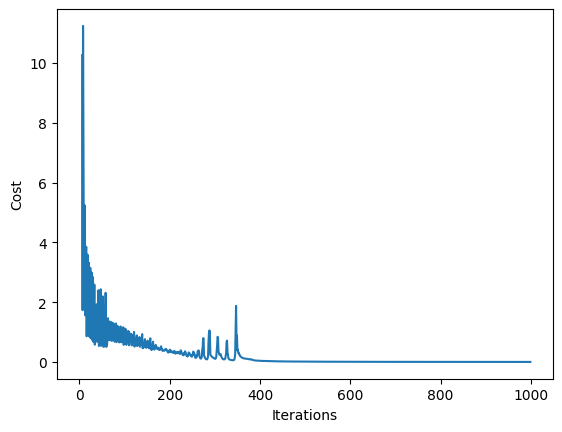

In [163]:
# Creating evenly spaced list from '0' to 'iters'
t = np.arange(0, iters)

# Plotting
plt.plot(t, cost_history)

# Labeling x-axis
plt.xlabel("Iterations")

# Labeling y-axis
plt.ylabel("Cost")

# Showing The Plot
plt.show()

# Making A Predictive System

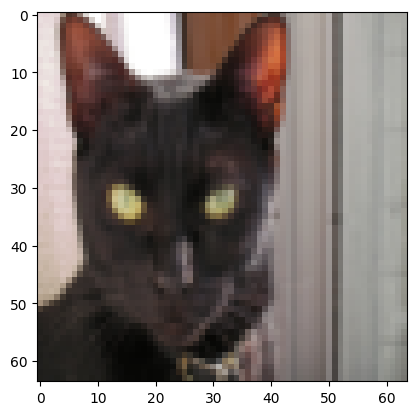

The Image Is A Cat.


In [171]:
# Displaying the image
index = random.randrange(0, X_test.shape[1])
plt.imshow(X_test[:, index].reshape(64,64,3)) # '64' is 'height', '64' is 'width' and '3' represents 'channels' i.e., red, green, blue.
plt.show()

# Making prediction
forwrd_cache, _= forward_propagation(X_test[:, index].reshape(X_test.shape[0], 1), parameters, "relu")

a_out = forwrd_cache

if a_out > 0.5:
  print("The Image Is A Cat.")
else:
  print("The Image Is Not A Cat.")



# Using The Model In Other Programs

1, Import requirements i.e., numpy, utils.py script.<br>

2, Download the **parameters.npz** file
<br>

3, Loading the **parameters.npz** file from **utils.py** script.
<br>

4, Use the **forward_propagation** function from **utils.py** script to predict the output.